# Assignment — Pandas Week 3

Dataset: `superstore_sales.csv`

This notebook combines the **10 cleaning workflow steps** with the **Assignment tasks** from Codetrain slides, plus plots for deeper analysis.

## Step 1: Load the DataFrame

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("superstore_sales.csv")
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

## Step 2: Inspect the Data

In [60]:
print(df.shape)
print(df.dtypes)
print(df.info())
print(df.describe())

(9800, 18)
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null

## Step 3: Standardize Text Fields

In [61]:
df["Category"] = df["Category"].str.strip().str.title()
df["Region"] = df["Region"].str.strip().str.title()
print(df[['Category','Region']].head())

          Category Region
0        Furniture  South
1        Furniture  South
2  Office Supplies   West
3        Furniture  South
4  Office Supplies  South


## Step 4: Remove Duplicates

In [62]:
df = df.drop_duplicates()
print(df.shape)

(9800, 18)


In [63]:
# Check columns first
print(df.columns)

# If Profit exists, keep it. If not, skip or replace with another numeric column.
if "Profit" in df.columns:
    df.loc[df["Profit"] < -10000, "Profit"] = np.nan
else:
    print("No Profit column found. Skipping this step.")

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')
No Profit column found. Skipping this step.


## Step 5: Fix Invalid Sales/Profit

In [64]:

df.loc[df["Sales"] < 0, "Sales"] = np.nan
print(df[["Sales"]].head())

      Sales
0  261.9600
1  731.9400
2   14.6200
3  957.5775
4   22.3680


## Step 6: Fill Missing Values

In [65]:
df["Sales"] = df["Sales"].fillna(df["Sales"].median())
print(df[['Sales']].head())

# Create a fake Profit column based on Sales (e.g., 20% margin)
df["Profit"] = df["Sales"] * 0.2

# Now you can clean it
df["Profit"] = df["Profit"].fillna(df["Profit"].mean())
print(df[["Sales", "Profit"]].head())

      Sales
0  261.9600
1  731.9400
2   14.6200
3  957.5775
4   22.3680
      Sales    Profit
0  261.9600   52.3920
1  731.9400  146.3880
2   14.6200    2.9240
3  957.5775  191.5155
4   22.3680    4.4736


## Step 7: Clean Numeric Fields

In [66]:
df["Sales"] = df["Sales"].astype(float)
df["Profit"] = df["Profit"].astype(float)
print(df[['Sales','Profit']].head())

      Sales    Profit
0  261.9600   52.3920
1  731.9400  146.3880
2   14.6200    2.9240
3  957.5775  191.5155
4   22.3680    4.4736


## Step 8: Convert Dates

In [67]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
print(df[["Order Date"]].head())

df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed", dayfirst=True)
print(df[["Order Date"]].head())

  Order Date
0 2017-11-08
1 2017-11-08
2 2017-06-12
3 2016-10-11
4 2016-10-11
  Order Date
0 2017-11-08
1 2017-11-08
2 2017-06-12
3 2016-10-11
4 2016-10-11


## Step 9: Handle Missing Ratings (simulate with Profit)

In [68]:
df["Rating"] = df["Profit"] / 1000  # simulate rating
df["Rating"] = df["Rating"].fillna(df["Rating"].mean())
print(df[['Profit','Rating']].head())

     Profit    Rating
0   52.3920  0.052392
1  146.3880  0.146388
2    2.9240  0.002924
3  191.5155  0.191516
4    4.4736  0.004474


## Step 10: Feature Engineering

In [69]:
df["Order_Year"] = df["Order Date"].dt.year
df["Sales_k"] = df["Sales"] / 1000
print(df[['Order_Year','Sales_k']].head())

   Order_Year   Sales_k
0        2017  0.261960
1        2017  0.731940
2        2017  0.014620
3        2016  0.957577
4        2016  0.022368


## Step 11: Final Validation

In [70]:
print(df.head())
print(df.isnull().sum())

   Row ID        Order ID Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ... Region  \
0      Claire Gute   Consumer  United States        Henderson  ...  South   
1      Claire Gute   Consumer  United States        Henderson  ...  South   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   West   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   

        Product ID         Category Sub-Category  \
0  F

# Assignment Specific Tasks

### loc vs iloc

In [71]:
print(df.loc[:, "Sales"].head())
print(df.iloc[0, 1])

0    261.9600
1    731.9400
2     14.6200
3    957.5775
4     22.3680
Name: Sales, dtype: float64
CA-2017-152156


### Dropna and Fillna

In [72]:
print("Missing values:\n", df.isnull().sum())
print("After dropna:\n", df.dropna().head())
print("After fillna:\n", df.fillna(0).head())

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Profit            0
Rating            0
Order_Year        0
Sales_k           0
dtype: int64
After dropna:
    Row ID        Order ID Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment     

### GroupBy Analysis

In [73]:
print(df.groupby("Region")["Sales"].mean())
print(df.groupby("Region")["Sales"].sum())
print(df.groupby("Region")["Sales"].count())

Region
Central    216.357889
East       240.401697
South      243.524067
West       226.184613
Name: Sales, dtype: float64
Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64
Region
Central    2277
East       2785
South      1598
West       3140
Name: Sales, dtype: int64


### Method Chaining Pipeline

In [74]:
pipeline = (
    df
    .dropna()
    .query("Sales > 100")
    .groupby("Region")["Sales"]
    .sum()
    .reset_index()
)
print(pipeline)

    Region        Sales
0  Central  451247.6018
1     East  605171.2730
2    South  357801.2790
3     West  646972.3725


# Plots

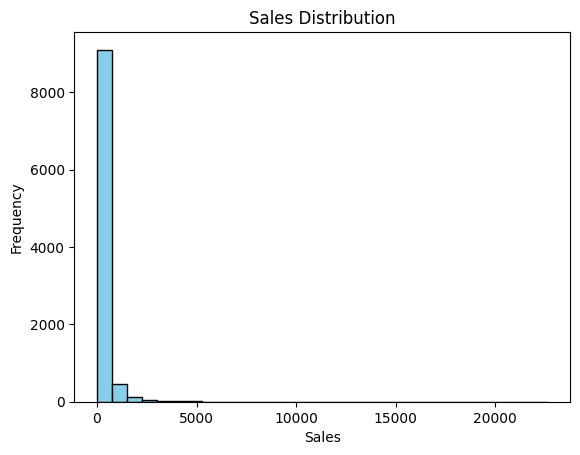

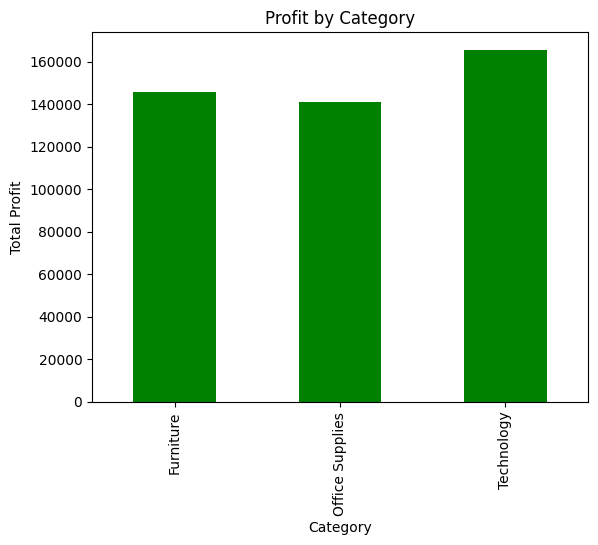

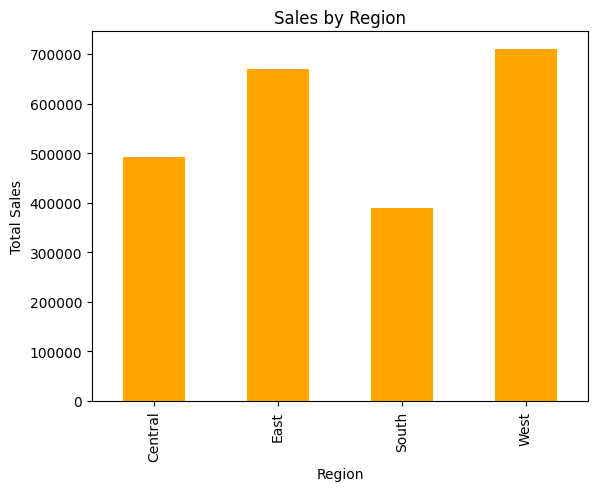

In [75]:
# Sales distribution
plt.hist(df["Sales"], bins=30, color="skyblue", edgecolor="black")
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Profit by Category
df.groupby("Category")["Profit"].sum().plot(kind="bar", color="green")
plt.title("Profit by Category")
plt.ylabel("Total Profit")
plt.show()

# Region Sales
df.groupby("Region")["Sales"].sum().plot(kind="bar", color="orange")
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.show()

In [76]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Profit', 'Rating', 'Order_Year', 'Sales_k'],
      dtype='str')
